# Libraries

In [1]:
import os
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from functions import *

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from UQpy.distributions import Normal, JointIndependent

mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False
})


d:\Documentos\ic_victor\myenv\Lib\site-packages\UQpy\__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Dataset

### Fixed vars

### $R$ and $S$ realization

In [2]:
# Number of realizations (ONE real beam)
n_samples = 1

# Latent uncertainty propagation
n_latent_samples = 2000

# Time discretization
time = [0., 10., 20., 30., 40., 50., 60., 70., 80., 90., 100.]


In [3]:
beam = {
    'b_w': 0.20,          # m
    'h': 0.25,            # m
    'f_ck': 40,           # MPa
    'g_k': 5.0,           # kN/m
    'q_k': 2.0,           # kN/m
    'l': 6.0,             # m

    'n_barras': 4,
    'd_0': 0.016,         # m (16 mm)
    'relacao_d_h': 0.84,

    'f_yk': 500,          # MPa
    'e_s': 200_000,       # MPa

    'i_corr_20': 1.0,     # μA/cm²
    'temperatura': 20,    # °C
    'tempo_iniciacao': 10,# anos
    'tempo_decorrido': 35,# anos

    'gamma_g': 1.0,
    'gamma_q': 1.0,
    'gamma_c': 1.0,
    'gamma_s': 1.0

}


In [4]:
xs = []

for t in time:
    beam['tempo_decorrido'] = t

    x_t = generate_x_from_real_beams_time(
        beams=[beam]
    )

    xs.append(x_t[0])  # [R(t), S]

xs



[array([72.55604005, 31.5       ]),
 array([72.55604005, 31.5       ]),
 array([61.93562453, 31.5       ]),
 array([52.95109228, 31.5       ]),
 array([47.78760272, 31.5       ]),
 array([44.0795009, 31.5      ]),
 array([41.13769442, 31.5       ]),
 array([38.66892141, 31.5       ]),
 array([36.52184631, 31.5       ]),
 array([34.60844748, 31.5       ]),
 array([32.87314382, 31.5       ])]

### $g$ over the time

In [5]:
lambdas = []
gs = []

for t in time:
    beam_t = beam.copy()
    beam_t['tempo_decorrido'] = t

    y, df = state_limit_function_time_real_beam(
        beams=[beam_t],
        n_latent_samples=n_latent_samples
    )

    lambdas.append(y[0])
    gs.append(df[0])

lambdas = np.vstack(lambdas)

lambdas



array([[4.10852925e+01, 3.93563017e-01, 1.33899509e-01, 1.94266612e-01],
       [4.11279312e+01, 4.08336203e-01, 8.28119792e-02, 1.59411461e-01],
       [3.06209135e+01, 4.35197841e-01, 9.23199947e-02, 1.40996482e-01],
       [2.16306769e+01, 4.51167726e-01, 7.82386181e-02, 1.51177224e-01],
       [1.64641336e+01, 4.89328657e-01, 3.16385814e-02, 1.17129301e-01],
       [1.26558778e+01, 4.49698469e-01, 1.10769040e-01, 1.49439502e-01],
       [9.79595757e+00, 4.36396146e-01, 9.36321191e-02, 1.72312034e-01],
       [7.35548900e+00, 4.58129679e-01, 7.63029483e-02, 1.85032995e-01],
       [5.24500727e+00, 4.56793029e-01, 1.09559323e-01, 1.88561238e-01],
       [3.23043499e+00, 4.59043052e-01, 7.29514484e-02, 1.69864025e-01],
       [1.48298351e+00, 4.71173355e-01, 8.64951044e-02, 1.76310208e-01]])

# Chart

### $g$ over the time

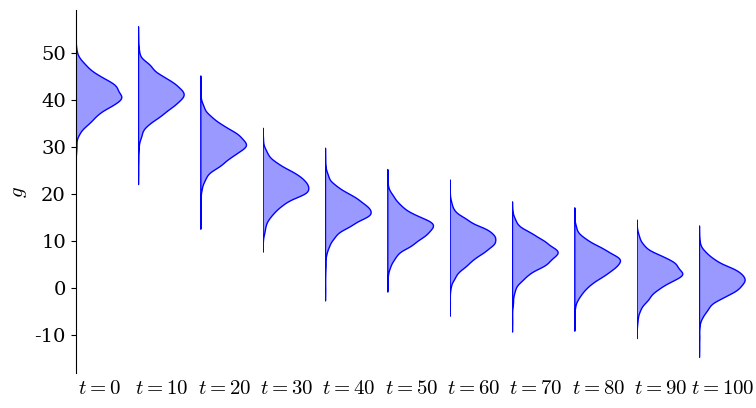

In [6]:
### Figure name and DPI
dpi = 600
name = 'time-lapse_g_analysis'

### Chart dimensions
b_cm_individual = 2.0      
h_cm = 12                 
inches_to_cm = 1 / 2.54

n_plots = len(time) 
b_input_total = (b_cm_individual * n_plots) * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels
label_y = '$g$'
size_label = 15
color_label = 'black'
size_axis = 14
color_axis = 'black'
color = 'blue'
alpha = 0.4

### Figure
fig, axes = plt.subplots(nrows=1, ncols=n_plots, sharey=True, figsize=(b_input_total, h_input))

### Space between plots
plt.subplots_adjust(wspace=0.3) 

### Loop
for i, ax in enumerate(axes):
    
    ### Plot
    current_data = gs[i]
    sns.kdeplot(y=current_data['g'], fill=True, alpha=alpha, ax=ax, color=color)
    
    # Configurações gerais (Fonte, Cor)
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    
    # Label X
    ax.set_xlabel(f'$t={int(time[i])}$', fontsize=size_label, color=color_label)
    
    # Remove ticks e números do eixo X (como você pediu antes)
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # Remove bordas padrão (Topo, Direita, Baixo)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # --- AQUI ESTÁ A MÁGICA PARA REMOVER O EIXO Y DOS OUTROS ---
    if i == 0:
        # Primeiro gráfico: Mantém a linha da esquerda e o Label Y
        ax.spines['left'].set_visible(True)
        ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
    else:
        # Do segundo em diante:
        ax.spines['left'].set_visible(False)   # Remove a linha vertical
        ax.tick_params(axis='y', left=False)   # Remove os tracinhos (ticks) da esquerda
        ax.set_ylabel('')                      # Remove o label
        
### Save and Show
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

### $\lambda$ over the time

In [7]:
y1 = lambdas[:,0]
y2 = lambdas[:,1]
y3 = lambdas[:,2]
y4 = lambdas[:,3]
data = [
        {'x': time, 'y': y1},
        {'x': time, 'y': y2},
        {'x': time, 'y': y3},
        {'x': time, 'y': y4}
    ]

### English version

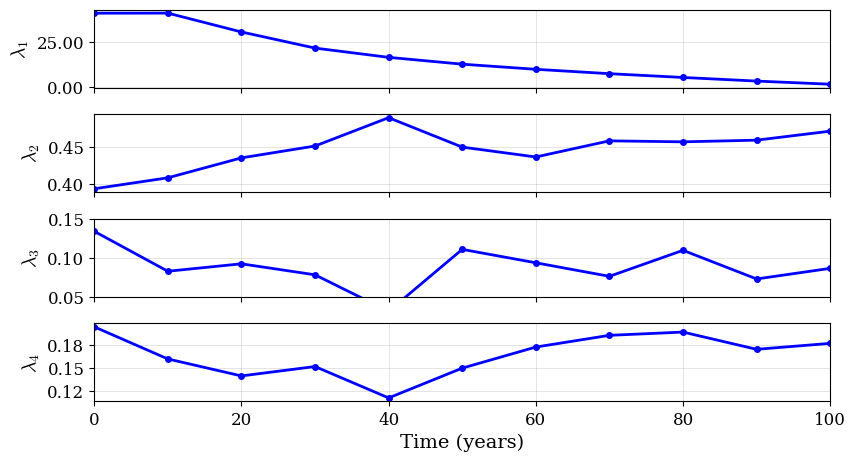

In [8]:
import matplotlib.ticker as ticker
### Figure name and DPI
dpi = 600
name = 'lambdas_for_r_s_realization'

### Axis and labels
label_x = 'Time (years)'  
size_label = 14
color_label = 'black'
size_axis = 12
color_axis = 'black'

### Line
size_line = 2
style_line = '-'
color_line = 'blue'

### Marker
marker = 'o'
size_marker = 4
color_marker = 'blue'
color_marker_edge = color_line

### Legend
labels_legend = ['$\lambda _1$', '$\lambda _2$', '$\lambda _3$', '$\lambda _4$']  # Change as you wish
size_legend = 10
location_legend = 'upper right'

### Grid
on_or_off = True
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

### Figure
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(b_input_total, h_input))

### Plot
i = 0
for ax, dataset in zip(axes, data):
    
    ax.plot(dataset['x'], dataset['y'],
            markerfacecolor=color_marker, marker=marker, markersize=size_marker,
            linewidth=size_line, linestyle=style_line, color=color_line)
    
    # Configuração dos Eixos (Cores e Tamanhos)
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    
    # Label Y (Específico de cada gráfico, mas com seu estilo)
    ax.set_ylabel(labels_legend[i], fontsize=size_label, color=color_label)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    i += 1
    
    # Configuração do Grid
    ax.grid(on_or_off, which='both', linestyle=style_grid, linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)
    
    # # Legenda
    # ax.legend(fontsize=size_legend, loc=location_legend)

# Ajuste específico para a Tangente (índice 2) pois ela vai ao infinito
axes[2].set_ylim(0.05, 0.15)

# Label X apenas no último gráfico
axes[-1].set_xlim(min(time), max(time))
axes[-1].set_xlabel(label_x, fontsize=size_label, color=color_label)

# Ajustar espaçamento
plt.tight_layout()

# --- 6. SALVAR E MOSTRAR ---
fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()

### Portuguese version

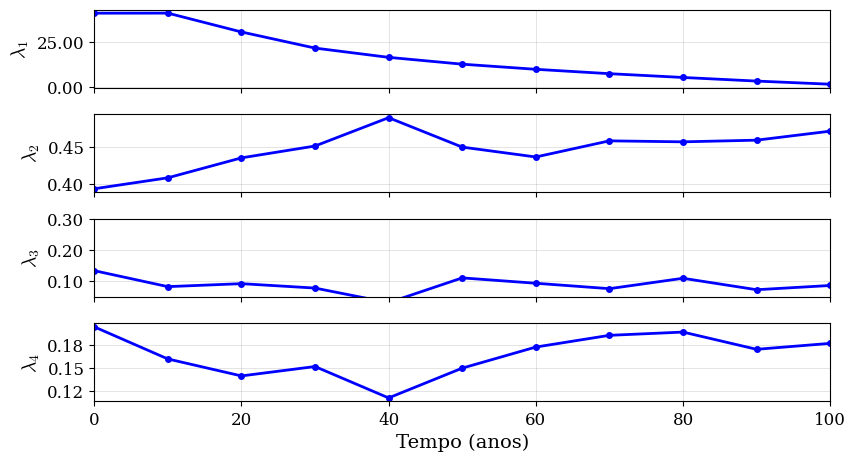

In [9]:
import matplotlib.ticker as ticker
### Figure name and DPI
dpi = 600
name = 'lambdas_for_r_s_realization'

### Axis and labels
label_x = 'Tempo (anos)'  
size_label = 14
color_label = 'black'
size_axis = 12
color_axis = 'black'

### Line
size_line = 2
style_line = '-'
color_line = 'blue'

### Marker
marker = 'o'
size_marker = 4
color_marker = 'blue'
color_marker_edge = color_line

### Legend
labels_legend = ['$\lambda _1$', '$\lambda _2$', '$\lambda _3$', '$\lambda _4$']  # Change as you wish
size_legend = 10
location_legend = 'upper right'

### Grid
on_or_off = True
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

### Figure
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(b_input_total, h_input))

### Plot
i = 0
for ax, dataset in zip(axes, data):
    
    ax.plot(dataset['x'], dataset['y'],
            markerfacecolor=color_marker, marker=marker, markersize=size_marker,
            linewidth=size_line, linestyle=style_line, color=color_line)
    
    # Configuração dos Eixos (Cores e Tamanhos)
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    
    # Label Y (Específico de cada gráfico, mas com seu estilo)
    ax.set_ylabel(labels_legend[i], fontsize=size_label, color=color_label)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    i += 1
    
    # Configuração do Grid
    ax.grid(on_or_off, which='both', linestyle=style_grid, linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)
    
    # # Legenda
    # ax.legend(fontsize=size_legend, loc=location_legend)

# Ajuste específico para a Tangente (índice 2) pois ela vai ao infinito
axes[2].set_ylim(0.05, 0.30)

# Label X apenas no último gráfico
axes[-1].set_xlim(min(time), max(time))
axes[-1].set_xlabel(label_x, fontsize=size_label, color=color_label)

# Ajustar espaçamento
plt.tight_layout()

# --- 6. SALVAR E MOSTRAR ---
fig.savefig(f'z_{name}_pt.png', dpi=dpi, bbox_inches='tight')
plt.show()